# Analise exploratoria SINAN: Ilheus e Itabuna (2014-2024)

Este notebook parte dos CSVs ja baixados e validados pelo script `sinan_pipeline.py`. Aqui ficam apenas a analise exploratoria, as series temporais e os rankings das cidades.

In [1]:
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

from sinan_pipeline import (
    AGRAVO_LABELS,
    AGRAVOS_ALVO,
    ANOS_ALVO,
    CITY_CODES,
    DATA_DIR,
    audit_downloads,
    build_candidate_inventory,
    build_city_counts,
    build_expected_file_map,
    build_monthly_city_counts,
    build_rankings,
    plot_rankings,
    summarize_audit,
)

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

expected_total_files = len(AGRAVOS_ALVO) * len(ANOS_ALVO)
print(f"Agravos no escopo: {len(AGRAVOS_ALVO)}")
print(f"Periodo: {ANOS_ALVO[0]} a {ANOS_ALVO[-1]}")
print(f"Arquivos esperados: {expected_total_files}")
print(f"Cidades: {CITY_CODES}")

Agravos no escopo: 28
Periodo: 2014 a 2024
Arquivos esperados: 308
Cidades: {'Ilheus': 291360, 'Itabuna': 291480}


## 1. Carregamento local e qualidade da base



In [2]:
_, expected_file_map = build_expected_file_map(
    AGRAVOS_ALVO,
    ANOS_ALVO,
    use_remote_catalog=False,
)

download_audit_df = audit_downloads(expected_file_map, DATA_DIR)
audit_summary_df = summarize_audit(download_audit_df)

display(audit_summary_df)

pendencias_df = download_audit_df.loc[
    download_audit_df["needs_download"] | download_audit_df["needs_reconvert"],
    ["agravo", "agravo_nome", "ano", "status", "csv_state", "parquet_state"],
].reset_index(drop=True)

if pendencias_df.empty:
    print("Base local completa para o escopo definido.")
else:
    print("Arquivos que ainda merecem nova tentativa pelo script de dados:")
    display(pendencias_df)

city_counts_df, skipped_files_df = build_city_counts(
    download_audit_df,
    CITY_CODES,
    DATA_DIR,
    AGRAVO_LABELS,
)
serie_anual_df = city_counts_df.copy()
ranking_ilheus_df, ranking_itabuna_df, ranking_geral_df = build_rankings(city_counts_df)

if not skipped_files_df.empty:
    print("Arquivos ignorados por problema estrutural:")
    display(skipped_files_df)

assert len(expected_file_map) == expected_total_files
assert (city_counts_df["casos"] <= city_counts_df["linhas_arquivo"]).all()
assert set(city_counts_df.loc[city_counts_df["agravo"] == "TRAC", "cidade_coluna"].unique()) == {"ID_MUNI_RE"}
assert set(city_counts_df.loc[city_counts_df["agravo"] == "NTRA", "cidade_coluna"].unique()) == {"ID_MUNICIP"}
print("Base analitica carregada com sucesso.")

,status,needs_download,needs_reconvert,arquivos
0,empty,False,False,8
1,present,False,False,300


Base local completa para o escopo definido.
Base analitica carregada com sucesso.


## 2. Panorama geral

Primeiro olhamos o volume total, quantos agravos tiveram notificacoes em cada cidade e como a serie anual se comporta no periodo.

In [3]:
totais_cidade_df = (
    serie_anual_df.groupby("cidade", as_index=False)["casos"]
    .sum()
    .rename(columns={"casos": "total_notificacoes"})
    .sort_values("total_notificacoes", ascending=False)
)

agravos_ativos_df = (
    serie_anual_df.groupby(["cidade", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
    .query("casos > 0")
    .groupby("cidade", as_index=False)
    .agg(agravos_com_notificacao=("agravo", "nunique"))
)

resumo_geral_df = totais_cidade_df.merge(agravos_ativos_df, on="cidade", how="left")
resumo_geral_df["media_anual"] = resumo_geral_df["total_notificacoes"] / len(ANOS_ALVO)
resumo_geral_df["media_anual"] = resumo_geral_df["media_anual"].round(1)

totais_ano_df = (
    serie_anual_df.groupby(["ano", "cidade"], as_index=False)["casos"]
    .sum()
    .pivot(index="ano", columns="cidade", values="casos")
    .fillna(0)
    .astype(int)
)
totais_ano_df["Total"] = totais_ano_df.sum(axis=1)

display(resumo_geral_df)
display(totais_ano_df)

,cidade,total_notificacoes,agravos_com_notificacao,media_anual
0,Itabuna,5420,18,492.7
1,Ilheus,4417,20,401.5


cidade,Ilheus,Itabuna,Total
ano,,,
2014,395,545,940
2015,380,483,863
2016,324,531,855
2017,375,575,950
2018,426,553,979
2019,497,583,1080
2020,282,391,673
2021,417,489,906
2022,569,525,1094


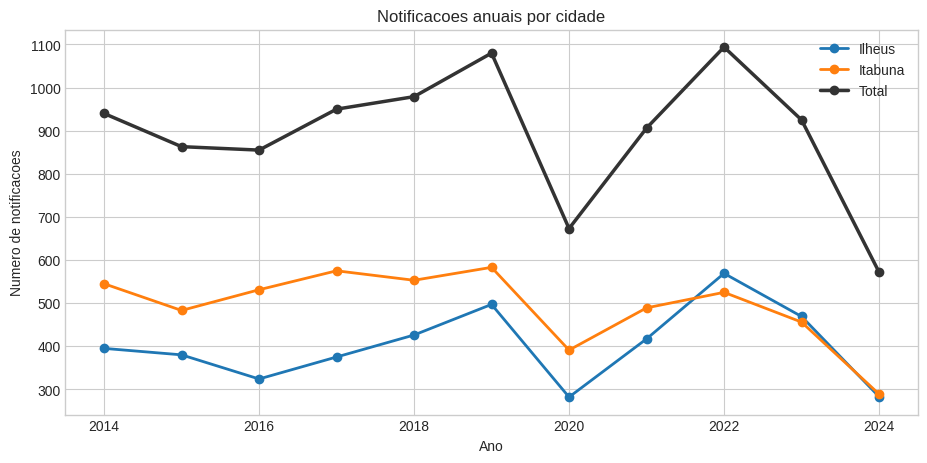

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
for cidade in CITY_CODES:
    ax.plot(totais_ano_df.index, totais_ano_df[cidade], marker="o", linewidth=2, label=cidade)
ax.plot(totais_ano_df.index, totais_ano_df["Total"], marker="o", linewidth=2.5, color="#333333", label="Total")
ax.set_title("Notificacoes anuais por cidade")
ax.set_xlabel("Ano")
ax.set_ylabel("Numero de notificacoes")
ax.legend()
plt.show()

## 3. Rankings e concentracao

Aqui mantemos o top 10 principal, mas tambem medimos o quanto poucos agravos concentram o total de notificacoes.

In [5]:
print("Top 10 - Ilheus")
display(ranking_ilheus_df)

print("Top 10 - Itabuna")
display(ranking_itabuna_df)

print("Top 10 - Consolidado")
display(ranking_geral_df)

ranking_completo_df = (
    serie_anual_df.groupby(["cidade", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
    .sort_values(["cidade", "casos", "agravo_nome"], ascending=[True, False, True])
)
ranking_completo_df["posicao"] = ranking_completo_df.groupby("cidade")["casos"].rank(
    method="first",
    ascending=False,
).astype(int)

concentracao_df = []
for cidade, grupo in ranking_completo_df.groupby("cidade"):
    total = grupo["casos"].sum()
    concentracao_df.append(
        {
            "cidade": cidade,
            "total_notificacoes": int(total),
            "top_1_pct": round(grupo.head(1)["casos"].sum() / total * 100, 1) if total else 0,
            "top_3_pct": round(grupo.head(3)["casos"].sum() / total * 100, 1) if total else 0,
            "top_10_pct": round(grupo.head(10)["casos"].sum() / total * 100, 1) if total else 0,
        }
    )
concentracao_df = pd.DataFrame(concentracao_df)
display(concentracao_df)

Top 10 - Ilheus


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,1489,Tuberculose (TUBE)
1,2,SIFA,Sifilis Adquirida,714,Sifilis Adquirida (SIFA)
2,3,SIFG,Sifilis em Gestante,564,Sifilis em Gestante (SIFG)
3,4,VARC,Varicela,534,Varicela (VARC)
4,5,SIFC,Sifilis Congenita,316,Sifilis Congenita (SIFC)
5,6,LTAN,Leishmaniose Tegumentar Americana,251,Leishmaniose Tegumentar Americana (LTAN)
6,7,HANS,Hanseniase,173,Hanseniase (HANS)
7,8,LEPT,Leptospirose,148,Leptospirose (LEPT)
8,9,MENI,Meningite,83,Meningite (MENI)
9,10,CHAG,Doenca de Chagas Aguda,61,Doenca de Chagas Aguda (CHAG)


Top 10 - Itabuna


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,1762,Tuberculose (TUBE)
1,2,SIFA,Sifilis Adquirida,1495,Sifilis Adquirida (SIFA)
2,3,SIFG,Sifilis em Gestante,605,Sifilis em Gestante (SIFG)
3,4,VARC,Varicela,511,Varicela (VARC)
4,5,HANS,Hanseniase,422,Hanseniase (HANS)
5,6,LEPT,Leptospirose,163,Leptospirose (LEPT)
6,7,MENI,Meningite,117,Meningite (MENI)
7,8,SIFC,Sifilis Congenita,116,Sifilis Congenita (SIFC)
8,9,LTAN,Leishmaniose Tegumentar Americana,60,Leishmaniose Tegumentar Americana (LTAN)
9,10,COQU,Coqueluche,42,Coqueluche (COQU)


Top 10 - Consolidado


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,3251,Tuberculose (TUBE)
1,2,SIFA,Sifilis Adquirida,2209,Sifilis Adquirida (SIFA)
2,3,SIFG,Sifilis em Gestante,1169,Sifilis em Gestante (SIFG)
3,4,VARC,Varicela,1045,Varicela (VARC)
4,5,HANS,Hanseniase,595,Hanseniase (HANS)
5,6,SIFC,Sifilis Congenita,432,Sifilis Congenita (SIFC)
6,7,LTAN,Leishmaniose Tegumentar Americana,311,Leishmaniose Tegumentar Americana (LTAN)
7,8,LEPT,Leptospirose,311,Leptospirose (LEPT)
8,9,MENI,Meningite,200,Meningite (MENI)
9,10,CHAG,Doenca de Chagas Aguda,61,Doenca de Chagas Aguda (CHAG)


,cidade,total_notificacoes,top_1_pct,top_3_pct,top_10_pct
0,Ilheus,4417,33.7,62.6,98.1
1,Itabuna,5420,32.5,71.3,97.7


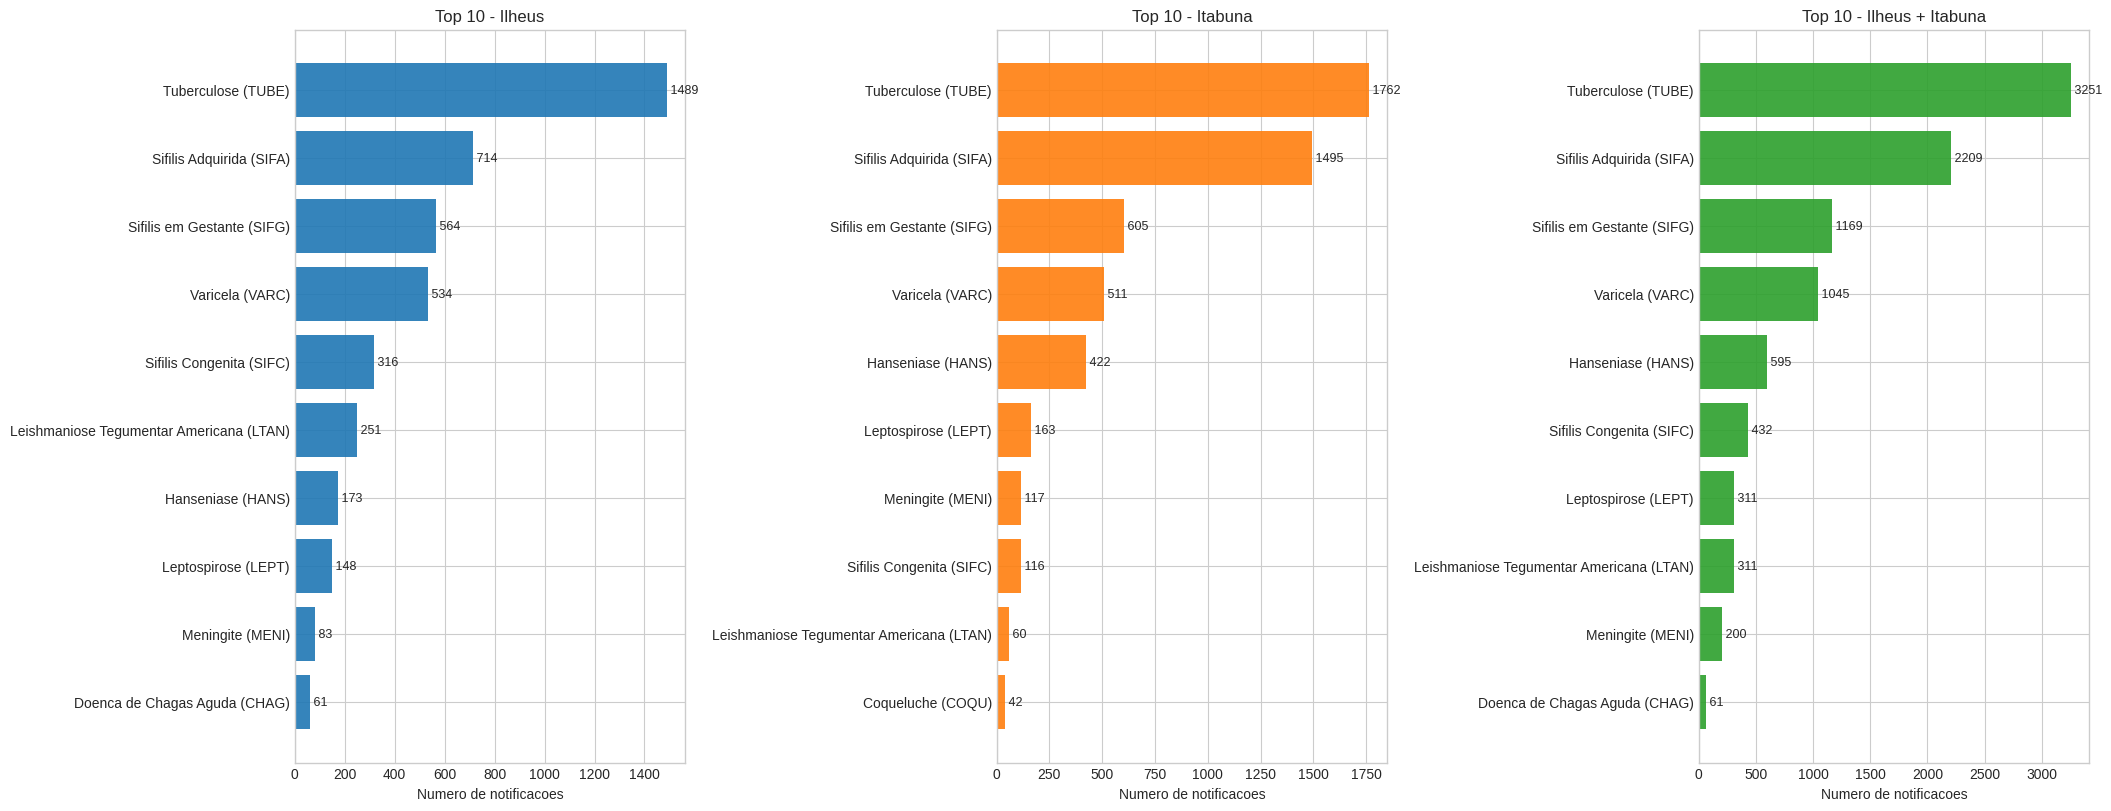

In [6]:
fig, axes = plot_rankings(ranking_ilheus_df, ranking_itabuna_df, ranking_geral_df)
plt.show()

## 4. Comparacao entre Ilheus e Itabuna

Este recorte mostra quais agravos pesam mais em uma cidade do que na outra, incluindo diferenca absoluta e razao entre os volumes.

cidade,agravo,agravo_nome,Ilheus,Itabuna,Total,diferenca_itabuna_menos_ilheus,razao_itabuna_ilheus,cidade_maior_volume
0,TUBE,Tuberculose,1489,1762,3251,273,1.18,Itabuna
1,SIFA,Sifilis Adquirida,714,1495,2209,781,2.09,Itabuna
2,SIFG,Sifilis em Gestante,564,605,1169,41,1.07,Itabuna
3,VARC,Varicela,534,511,1045,-23,0.96,Ilheus
4,HANS,Hanseniase,173,422,595,249,2.44,Itabuna
5,SIFC,Sifilis Congenita,316,116,432,-200,0.37,Ilheus
6,LTAN,Leishmaniose Tegumentar Americana,251,60,311,-191,0.24,Ilheus
7,LEPT,Leptospirose,148,163,311,15,1.10,Itabuna
8,MENI,Meningite,83,117,200,34,1.41,Itabuna
9,CHAG,Doenca de Chagas Aguda,61,0,61,-61,0.00,Ilheus


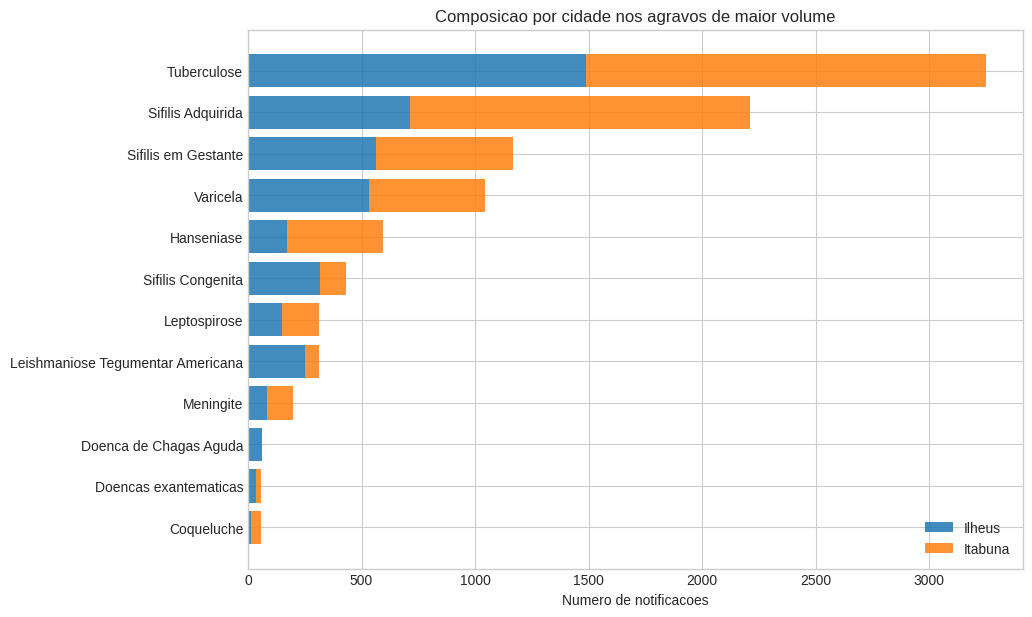

In [7]:
comparacao_cidades_df = (
    serie_anual_df.groupby(["agravo", "agravo_nome", "cidade"], as_index=False)["casos"]
    .sum()
    .pivot(index=["agravo", "agravo_nome"], columns="cidade", values="casos")
    .fillna(0)
    .astype(int)
    .reset_index()
)
comparacao_cidades_df["Total"] = comparacao_cidades_df["Ilheus"] + comparacao_cidades_df["Itabuna"]
comparacao_cidades_df["diferenca_itabuna_menos_ilheus"] = comparacao_cidades_df["Itabuna"] - comparacao_cidades_df["Ilheus"]
comparacao_cidades_df["razao_itabuna_ilheus"] = (
    comparacao_cidades_df["Itabuna"] / comparacao_cidades_df["Ilheus"].replace(0, float("nan"))
).round(2)
comparacao_cidades_df["cidade_maior_volume"] = comparacao_cidades_df.apply(
    lambda row: "Itabuna" if row["Itabuna"] > row["Ilheus"] else ("Ilheus" if row["Ilheus"] > row["Itabuna"] else "Empate"),
    axis=1,
)
comparacao_cidades_df = comparacao_cidades_df.sort_values("Total", ascending=False).reset_index(drop=True)

display(comparacao_cidades_df.head(15))

plot_df = comparacao_cidades_df.head(12).sort_values("Total")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["agravo_nome"], plot_df["Ilheus"], label="Ilheus", color="#1f77b4", alpha=0.85)
ax.barh(plot_df["agravo_nome"], plot_df["Itabuna"], left=plot_df["Ilheus"], label="Itabuna", color="#ff7f0e", alpha=0.85)
ax.set_title("Composicao por cidade nos agravos de maior volume")
ax.set_xlabel("Numero de notificacoes")
ax.set_ylabel("")
ax.legend()
plt.show()

## 5. Evolucao temporal dos principais agravos

Agora observamos se os maiores agravos foram constantes no tempo ou se houve picos especificos em alguns anos.

cidade,ano,agravo,agravo_nome,Ilheus,Itabuna
0,2014,HANS,Hanseniase,16,46
1,2014,SIFA,Sifilis Adquirida,2,110
2,2014,SIFC,Sifilis Congenita,2,10
3,2014,SIFG,Sifilis em Gestante,8,79
4,2014,TUBE,Tuberculose,114,141
5,2014,VARC,Varicela,156,78
6,2015,HANS,Hanseniase,18,38
7,2015,SIFA,Sifilis Adquirida,2,120
8,2015,SIFC,Sifilis Congenita,17,22
9,2015,SIFG,Sifilis em Gestante,35,74


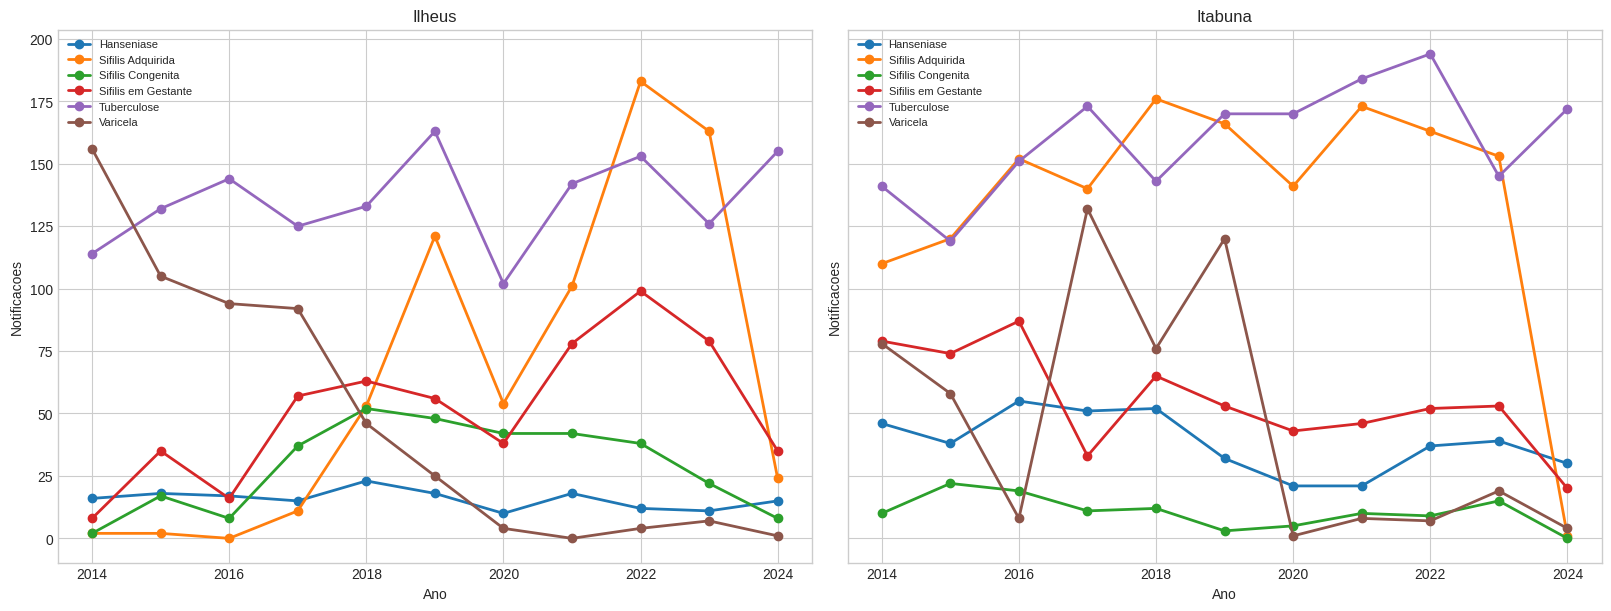

In [8]:
top_codes = ranking_geral_df.head(6)["agravo"].tolist()
evolucao_top_df = (
    serie_anual_df.loc[serie_anual_df["agravo"].isin(top_codes)]
    .groupby(["ano", "cidade", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
)

display(
    evolucao_top_df.pivot_table(
        index=["ano", "agravo", "agravo_nome"],
        columns="cidade",
        values="casos",
        aggfunc="sum",
        fill_value=0,
    ).reset_index().head(30)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, constrained_layout=True)
for ax, cidade in zip(axes, CITY_CODES):
    base = evolucao_top_df.loc[evolucao_top_df["cidade"] == cidade]
    for agravo, grupo in base.groupby("agravo"):
        label = AGRAVO_LABELS.get(agravo, agravo)
        ax.plot(grupo["ano"], grupo["casos"], marker="o", linewidth=2, label=label)
    ax.set_title(cidade)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Notificacoes")
    ax.legend(fontsize=8)
plt.show()

## 6. Mudanca entre periodos

Para enxergar deslocamentos de tendencia, comparamos 2014-2018 contra 2019-2024 em cada cidade.

In [9]:
serie_periodo_df = serie_anual_df.copy()
serie_periodo_df["periodo"] = serie_periodo_df["ano"].apply(
    lambda ano: "2014-2018" if ano <= 2018 else "2019-2024"
)

periodos_df = (
    serie_periodo_df.groupby(["cidade", "agravo", "agravo_nome", "periodo"], as_index=False)["casos"]
    .sum()
    .pivot(index=["cidade", "agravo", "agravo_nome"], columns="periodo", values="casos")
    .fillna(0)
    .reset_index()
)
periodos_df["variacao_abs"] = periodos_df["2019-2024"] - periodos_df["2014-2018"]
periodos_df["variacao_pct"] = (
    periodos_df["variacao_abs"] / periodos_df["2014-2018"].replace(0, float("nan")) * 100
).round(1)
periodos_df["Total"] = periodos_df["2014-2018"] + periodos_df["2019-2024"]

print("Maiores aumentos absolutos")
display(periodos_df.sort_values("variacao_abs", ascending=False).head(15))

print("Maiores quedas absolutas")
display(periodos_df.sort_values("variacao_abs", ascending=True).head(15))

Maiores aumentos absolutos


periodo,cidade,agravo,agravo_nome,2014-2018,2019-2024,variacao_abs,variacao_pct,Total
19,Ilheus,SIFA,Sifilis Adquirida,68,646,578,850.0,714
54,Itabuna,TUBE,Tuberculose,727,1035,308,42.4,1762
21,Ilheus,SIFG,Sifilis em Gestante,179,385,206,115.1,564
26,Ilheus,TUBE,Tuberculose,648,841,193,29.8,1489
47,Itabuna,SIFA,Sifilis Adquirida,698,797,99,14.2,1495
20,Ilheus,SIFC,Sifilis Congenita,116,200,84,72.4,316
0,Ilheus,CHAG,Doenca de Chagas Aguda,0,61,61,NaN,61
39,Itabuna,LEPT,Leptospirose,58,105,47,81.0,163
41,Itabuna,MALA,Malaria,1,31,30,3000.0,32
30,Itabuna,DERM,Dermatoses ocupacionais,3,22,19,633.3,25


Maiores quedas absolutas


periodo,cidade,agravo,agravo_nome,2014-2018,2019-2024,variacao_abs,variacao_pct,Total
27,Ilheus,VARC,Varicela,493,41,-452,-91.7,534
55,Itabuna,VARC,Varicela,352,159,-193,-54.8,511
49,Itabuna,SIFG,Sifilis em Gestante,338,267,-71,-21.0,605
12,Ilheus,LTAN,Leishmaniose Tegumentar Americana,160,91,-69,-43.1,251
36,Itabuna,HANS,Hanseniase,242,180,-62,-25.6,422
40,Itabuna,LTAN,Leishmaniose Tegumentar Americana,46,14,-32,-69.6,60
29,Itabuna,COQU,Coqueluche,37,5,-32,-86.5,42
48,Itabuna,SIFC,Sifilis Congenita,74,42,-32,-43.2,116
42,Itabuna,MENI,Meningite,71,46,-25,-35.2,117
32,Itabuna,ESQU,Esquistossomose,27,4,-23,-85.2,31


## 7. Anos de pico e mapa de calor

Este bloco ajuda a identificar em quais anos cada agravo concentrou mais notificacoes no consolidado das duas cidades.

,agravo,agravo_nome,ano_pico,casos_no_pico
0,TUBE,Tuberculose,2022,347
1,SIFA,Sifilis Adquirida,2022,346
2,VARC,Varicela,2014,234
3,SIFG,Sifilis em Gestante,2022,151
4,HANS,Hanseniase,2018,75
5,LEPT,Leptospirose,2022,75
6,LTAN,Leishmaniose Tegumentar Americana,2014,70
7,SIFC,Sifilis Congenita,2018,64
8,MALA,Malaria,2021,27
9,MENI,Meningite,2015,26


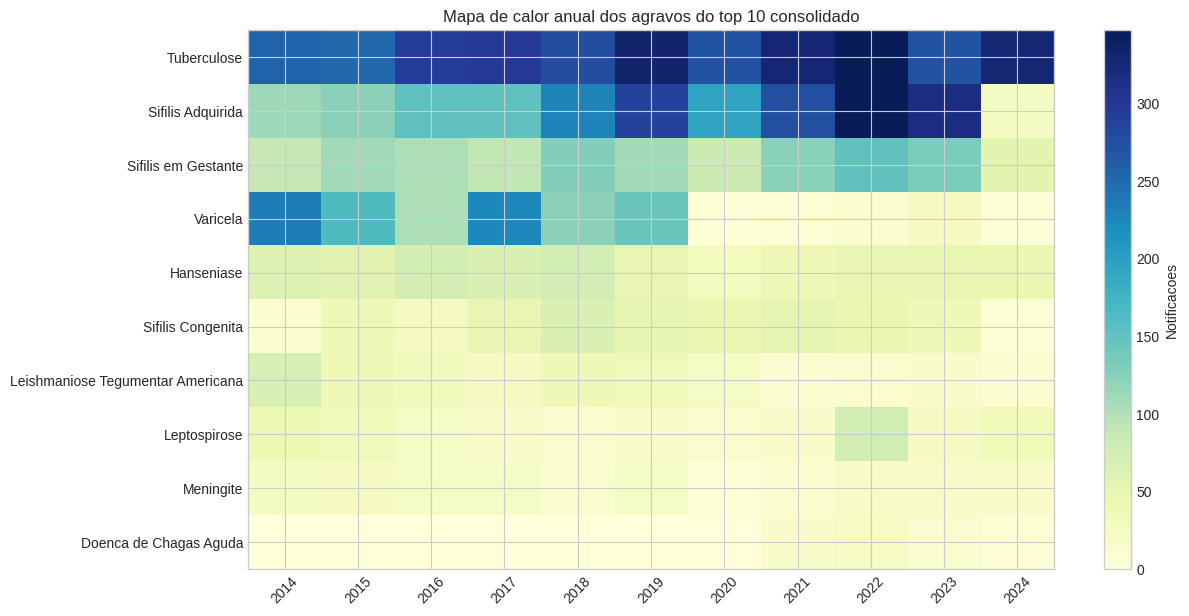

In [10]:
serie_total_agravo_ano_df = (
    serie_anual_df.groupby(["ano", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
)

picos_df = (
    serie_total_agravo_ano_df.sort_values(["agravo", "casos"], ascending=[True, False])
    .groupby(["agravo", "agravo_nome"], as_index=False)
    .first()
    .rename(columns={"ano": "ano_pico", "casos": "casos_no_pico"})
    .sort_values("casos_no_pico", ascending=False)
    .reset_index(drop=True)
)

display(picos_df.head(15))

heatmap_codes = ranking_geral_df["agravo"].tolist()
heatmap_df = (
    serie_total_agravo_ano_df.loc[serie_total_agravo_ano_df["agravo"].isin(heatmap_codes)]
    .pivot(index="agravo_nome", columns="ano", values="casos")
    .fillna(0)
)
heatmap_df = heatmap_df.loc[ranking_geral_df.set_index("agravo")["agravo_nome"]]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("Mapa de calor anual dos agravos do top 10 consolidado")
fig.colorbar(im, ax=ax, label="Notificacoes")
plt.show()

## 8. Direcionamento para o projeto preditivo

O objetivo final do projeto nao e apenas descrever o passado. A ideia e escolher uma doenca com base historica suficientemente consistente e, a partir dela, construir modelos preditivos de inteligencia artificial para estimar a incidencia em 2025 e 2026.

Neste ponto, eu nao devo escolher a doenca apenas porque ela aparece no top 10. Para uma previsao minimamente defensavel, eu preciso observar se a serie tem volume, continuidade mensal, poucos meses zerados, variacao temporal interpretavel e possibilidade de ser enriquecida com outras fontes confiaveis. Por isso, a proxima etapa do notebook cria um inventario automatico das doencas candidatas.

In [11]:
monthly_counts_df, monthly_issues_df = build_monthly_city_counts(
    download_audit_df,
    CITY_CODES,
    DATA_DIR,
    AGRAVO_LABELS,
)
candidate_inventory_df = build_candidate_inventory(monthly_counts_df)

if not monthly_issues_df.empty:
    print("Arquivos sem coluna de data/cidade suficiente para a serie mensal:")
    display(monthly_issues_df)

colunas_inventario = [
    "agravo",
    "agravo_nome",
    "score_modelagem",
    "total_casos",
    "media_mensal",
    "max_mensal",
    "meses_com_caso",
    "pct_meses_zerados",
    "casos_2014_2018",
    "casos_2019_2024",
    "variacao_abs_periodos",
    "indice_sazonalidade",
]

display(candidate_inventory_df[colunas_inventario].head(15))

,agravo,agravo_nome,score_modelagem,total_casos,media_mensal,max_mensal,meses_com_caso,pct_meses_zerados,casos_2014_2018,casos_2019_2024,variacao_abs_periodos,indice_sazonalidade
0,TUBE,Tuberculose,98.4,3095,23.45,41,132,0.0,1300,1795,495,0.10
1,SIFA,Sifilis Adquirida,93.8,2209,16.73,54,121,8.3,766,1443,677,0.15
2,SIFG,Sifilis em Gestante,90.7,1169,8.86,21,127,3.8,517,652,135,0.12
3,HANS,Hanseniase,88.9,595,4.51,17,128,3.0,331,264,-67,0.26
4,VARC,Varicela,82.3,1045,7.92,53,90,31.8,845,200,-645,0.50
5,SIFC,Sifilis Congenita,82.1,432,3.27,15,110,16.7,190,242,52,0.27
6,LEPT,Leptospirose,80.0,311,2.36,51,105,20.5,128,183,55,0.47
7,LTAN,Leishmaniose Tegumentar Americana,80.0,311,2.36,22,109,17.4,206,105,-101,0.28
8,MENI,Meningite,70.4,200,1.52,5,97,26.5,109,91,-18,0.31
9,EXAN,Doencas exantematicas,65.4,58,0.44,7,36,72.7,29,29,0,0.89


Transformei a serie anual em serie mensal, porque modelos preditivos precisam de mais pontos no tempo. Com dados de 2014 a 2024, a granularidade mensal produz aproximadamente 132 meses por cidade, o que e muito mais adequado do que apenas 11 anos.

Em seguida, eu avaliei cada agravo por criterios objetivos: volume total de notificacoes, media mensal, quantidade de meses com pelo menos um caso, percentual de meses zerados, diferenca entre 2014-2018 e 2019-2024 e um indice simples de sazonalidade. O `score_modelagem` nao e um resultado epidemiologico; ele e apenas uma triagem tecnica para indicar quais doencas parecem mais adequadas para modelagem preditiva.

In [12]:
shortlist_df = candidate_inventory_df.loc[
    (candidate_inventory_df["total_casos"] >= 200)
    & (candidate_inventory_df["pct_meses_zerados"] <= 45)
].copy()

display(shortlist_df[colunas_inventario].head(10))

melhor_candidato = shortlist_df.iloc[0] if not shortlist_df.empty else candidate_inventory_df.iloc[0]
print("Candidato tecnico mais forte no recorte atual:")
print(f"{melhor_candidato['agravo_nome']} ({melhor_candidato['agravo']})")
print(f"Total de notificacoes: {int(melhor_candidato['total_casos'])}")
print(f"Meses zerados: {melhor_candidato['pct_meses_zerados']}%")
print(f"Score de modelagem: {melhor_candidato['score_modelagem']}")

,agravo,agravo_nome,score_modelagem,total_casos,media_mensal,max_mensal,meses_com_caso,pct_meses_zerados,casos_2014_2018,casos_2019_2024,variacao_abs_periodos,indice_sazonalidade
0,TUBE,Tuberculose,98.4,3095,23.45,41,132,0.0,1300,1795,495,0.10
1,SIFA,Sifilis Adquirida,93.8,2209,16.73,54,121,8.3,766,1443,677,0.15
2,SIFG,Sifilis em Gestante,90.7,1169,8.86,21,127,3.8,517,652,135,0.12
3,HANS,Hanseniase,88.9,595,4.51,17,128,3.0,331,264,-67,0.26
4,VARC,Varicela,82.3,1045,7.92,53,90,31.8,845,200,-645,0.50
5,SIFC,Sifilis Congenita,82.1,432,3.27,15,110,16.7,190,242,52,0.27
6,LEPT,Leptospirose,80.0,311,2.36,51,105,20.5,128,183,55,0.47
7,LTAN,Leishmaniose Tegumentar Americana,80.0,311,2.36,22,109,17.4,206,105,-101,0.28
8,MENI,Meningite,70.4,200,1.52,5,97,26.5,109,91,-18,0.31


Candidato tecnico mais forte no recorte atual:
Tuberculose (TUBE)
Total de notificacoes: 3095
Meses zerados: 0.0%
Score de modelagem: 98.4


A partir deste inventario, o proximo passo e escolher uma doenca candidata e montar uma base mensal final com: notificacoes do SINAN, taxa por 100 mil habitantes, possiveis internacoes no SIH, possiveis obitos no SIM e variaveis climaticas do INMET. Depois disso, a serie pode ser separada em treino e teste temporal para comparar modelos simples de referencia com modelos de aprendizado de maquina.